# **Pemodelan Data Berdimensi Tinggi untuk Prediksi Tingkat Kriminalitas menggunakan Metode Regularisasi**

# **Dataset**

Data yang digunakan ialah "Communities and Crime" yang merupakan gabungan dari data sosio-ekonomi dari Sensus AS tahun 1990, data penegak hukum dari survei LEMAS AS tahun 1990, dan data kejahatan dari FBI UCR tahun 1995. Data memiliki 1.994 instansi (baris) yang mewakili berbagai komunitas (kota/wilayah) di Amerika Serikat dan 128 variabel (kolom). Data ini berasal dari UC Irvine dengan link https://archive.ics.uci.edu/dataset/183/communities+and+crime

Data "Communities and Crime" juga memiliki 122 atribut yang mencakup profil komunitas (pendapatan, populasi urban) dan data penegak hukum. Seluruh data numerik telah dinormalisasi ke rentang 0.00 hingga 1.00 untuk memudahkan proses analisis, dengan tetap mempertahankan distribusi data aslinya. Selain itu, beberapa wilayah (seperti Midwest) tidak disertakan dalam dataset karena adanya inkonsistensi pelaporan data kejahatan pada periode tersebut.

## **Variabel**

**Informasi Atribut Dataset**

**Identitas & Administrasi (Non-Prediktif):**
* `state`: Kode negara bagian Amerika Serikat (nominal).
* `county`: Kode numerik untuk wilayah kabupaten (banyak data kosong).
* `community`: Kode numerik untuk komunitas (banyak data kosong).
* `communityname`: Nama komunitas/kota (string).
* `fold`: Nomor lipatan untuk validasi silang 10-kali (tidak untuk prediksi).

**Profil Demografi Dasar:**
* `population`: Jumlah populasi komunitas.
* `householdsize`: Rata-rata jumlah orang per rumah tangga.
* `racepctblack`: Persentase populasi keturunan Afrika-Amerika.
* `racePctWhite`: Persentase populasi keturunan Kaukasia (Putih).
* `racePctAsian`: Persentase populasi keturunan Asia.
* `racePctHisp`: Persentase populasi keturunan Hispanik.
* `agePct12t21`: Persentase populasi usia 12-21 tahun.
* `agePct12t29`: Persentase populasi usia 12-29 tahun.
* `agePct16t24`: Persentase populasi usia 16-24 tahun.
* `agePct65up`: Persentase populasi usia 65 tahun ke atas.
* `numbUrban`: Jumlah penduduk yang tinggal di area perkotaan (urban).
* `pctUrban`: Persentase penduduk yang tinggal di area perkotaan.

**Ekonomi & Pendapatan:**
* `medIncome`: Median pendapatan rumah tangga.
* `pctWWage`: Persentase rumah tangga dengan pendapatan gaji atau upah pada tahun 1989.
* `pctWFarmSelf`: Persentase rumah tangga dengan pendapatan tani atau wiraswasta.
* `pctWInvInc`: Persentase rumah tangga dengan pendapatan investasi/sewa.
* `pctWSocSec`: Persentase rumah tangga dengan pendapatan jaminan sosial.
* `pctWPubAsst`: Persentase rumah tangga dengan bantuan publik (bansos).
* `pctWRetire`: Persentase rumah tangga dengan pendapatan pensiun.
* `medFamInc`: Median pendapatan keluarga.
* `perCapInc`: Pendapatan per kapita.
* `whitePerCap`: Pendapatan per kapita untuk etnis Kaukasia.
* `blackPerCap`: Pendapatan per kapita untuk etnis Afrika-Amerika.
* `indianPerCap`: Pendapatan per kapita untuk penduduk asli Amerika (Indian).
* `AsianPerCap`: Pendapatan per kapita untuk etnis Asia.
* `OtherPerCap`: Pendapatan per kapita untuk etnis 'lainnya'.
* `HispPerCap`: Pendapatan per kapita untuk etnis Hispanik.
* `NumUnderPov`: Jumlah orang di bawah garis kemiskinan.
* `PctPopUnderPov`: Persentase orang di bawah garis kemiskinan.

**Pendidikan & Pekerjaan:**
* `PctLess9thGrade`: Persentase penduduk usia 25+ dengan pendidikan di bawah kelas 9.
* `PctNotHSGrad`: Persentase penduduk usia 25+ yang tidak lulus SMA.
* `PctBSorMore`: Persentase penduduk usia 25+ dengan gelar sarjana atau lebih tinggi.
* `PctUnemployed`: Persentase pengangguran (usia 16+ dalam angkatan kerja).
* `PctEmploy`: Persentase penduduk usia 16+ yang bekerja.
* `PctEmplManu`: Persentase penduduk usia 16+ yang bekerja di sektor manufaktur.
* `PctEmplProfServ`: Persentase penduduk usia 16+ yang bekerja di layanan profesional.
* `PctOccupManu`: Persentase penduduk usia 16+ yang bekerja di sektor manufaktur (pekerjaan fisik).
* `PctOccupMgmtProf`: Persentase penduduk usia 16+ di posisi manajemen atau profesional.

**Struktur Keluarga:**
* `MalePctDivorce`: Persentase laki-laki yang bercerai.
* `MalePctNevMarr`: Persentase laki-laki yang belum pernah menikah.
* `FemalePctDiv`: Persentase perempuan yang bercerai.
* `TotalPctDiv`: Persentase total populasi yang bercerai.
* `PersPerFam`: Rata-rata jumlah orang per keluarga.
* `PctFam2Par`: Persentase keluarga (dengan anak) yang dipimpin dua orang tua.
* `PctKids2Par`: Persentase anak-anak dalam perumahan keluarga dengan dua orang tua.
* `PctYoungKids2Par`: Persentase anak usia 4 tahun ke bawah dengan dua orang tua.
* `PctTeen2Par`: Persentase remaja usia 12-17 dengan dua orang tua.
* `PctWorkMomYoungKids`: Persentase ibu dengan anak usia 6 tahun ke bawah yang bekerja.
* `PctWorkMom`: Persentase ibu dengan anak di bawah 18 tahun yang bekerja.
* `NumIlleg`: Jumlah anak yang lahir dari ibu yang belum pernah menikah.
* `PctIlleg`: Persentase anak yang lahir dari ibu yang belum pernah menikah.

**Imigrasi & Bahasa:**
* `NumImmig`: Total jumlah penduduk kelahiran luar negeri (imigran).
* `PctImmigRecent`: Persentase imigran yang datang dalam 3 tahun terakhir.
* `PctImmigRec5`: Persentase imigran yang datang dalam 5 tahun terakhir.
* `PctImmigRec8`: Persentase imigran yang datang dalam 8 tahun terakhir.
* `PctImmigRec10`: Persentase imigran yang datang dalam 10 tahun terakhir.
* `PctRecentImmig`: Persentase total populasi yang berimigrasi dalam 3 tahun terakhir.
* `PctRecImmig5`: Persentase total populasi yang berimigrasi dalam 5 tahun terakhir.
* `PctRecImmig8`: Persentase total populasi yang berimigrasi dalam 8 tahun terakhir.
* `PctRecImmig10`: Persentase total populasi yang berimigrasi dalam 10 tahun terakhir.
* `PctSpeakEnglOnly`: Persentase penduduk yang hanya berbicara bahasa Inggris.
* `PctNotSpeakEnglWell`: Persentase penduduk yang tidak lancar berbahasa Inggris.

**Perumahan:**
* `PctLargHouseFam`: Persentase keluarga besar (6 orang atau lebih).
* `PctLargHouseOccup`: Persentase semua rumah tangga berpenghuni yang besar.
* `PersPerOccupHous`: Rata-rata orang per rumah tangga berpenghuni.
* `PersPerOwnOccHous`: Rata-rata orang per rumah milik sendiri.
* `PersPerRentOccHous`: Rata-rata orang per rumah sewa.
* `PctPersOwnOccup`: Persentase orang yang tinggal di rumah milik sendiri.
* `PctPersDenseHous`: Persentase orang di hunian padat (lebih dari 1 orang per kamar).
* `PctHousLess3BR`: Persentase rumah dengan kurang dari 3 kamar tidur.
* `MedNumBR`: Median jumlah kamar tidur.
* `HousVacant`: Jumlah rumah yang kosong.
* `PctHousOccup`: Persentase rumah yang berpenghuni.
* `PctHousOwnOcc`: Persentase rumah tangga yang memiliki rumah sendiri.
* `PctVacantBoarded`: Persentase rumah kosong yang ditutup papan kayu.
* `PctVacMore6Mos`: Persentase rumah kosong selama lebih dari 6 bulan.
* `MedYrHousBuilt`: Median tahun pembangunan rumah.
* `PctHousNoPhone`: Persentase rumah tangga tanpa telepon.
* `PctWOFullPlumb`: Persentase rumah tanpa fasilitas pipa air/plumbing lengkap.
* `OwnOccLowQuart`: Nilai kuartil bawah rumah milik sendiri.
* `OwnOccMedVal`: Median nilai rumah milik sendiri.
* `OwnOccHiQuart`: Nilai kuartil atas rumah milik sendiri.
* `RentLowQ`: Harga sewa kuartil bawah.
* `RentMedian`: Median harga sewa (STF1A).
* `RentHighQ`: Harga sewa kuartil atas.
* `MedRent`: Median sewa kotor (termasuk utilitas).
* `MedRentPctHousInc`: Median persentase sewa terhadap pendapatan rumah tangga.
* `MedOwnCostPctInc`: Median biaya pemilik terhadap pendapatan (dengan hipotek).
* `MedOwnCostPctIncNoMtg`: Median biaya pemilik terhadap pendapatan (tanpa hipotek).
* `NumInShelters`: Jumlah orang di penampungan tunawisma.
* `NumStreet`: Jumlah tunawisma yang terhitung di jalanan.
* `PctForeignBorn`: Persentase orang kelahiran luar negeri.
* `PctBornSameState`: Persentase orang yang lahir di negara bagian yang sama dengan tempat tinggal sekarang.
* `PctSameHouse85`: Persentase orang di rumah yang sama seperti tahun 1985.
* `PctSameCity85`: Persentase orang di kota yang sama seperti tahun 1985.
* `PctSameState85`: Persentase orang di negara bagian yang sama seperti tahun 1985.

**Data Kepolisian (LEMAS):**
* `LemasSwornFT`: Jumlah polisi purna waktu bersumpah.
* `LemasSwFTPerPop`: Polisi purna waktu per 100 ribu penduduk.
* `LemasSwFTFieldOps`: Jumlah polisi di operasional lapangan.
* `LemasSwFTFieldPerPop`: Polisi lapangan per 100 ribu penduduk.
* `LemasTotalReq`: Total permintaan polisi.
* `LemasTotReqPerPop`: Total permintaan polisi per 100 ribu penduduk.
* `PolicReqPerOffic`: Total permintaan polisi per petugas.
* `PolicPerPop`: Petugas polisi per 100 ribu penduduk.
* `RacialMatchCommPol`: Tingkat kecocokan ras antara komunitas dan kepolisian.
* `PctPolicWhite`: Persentase polisi keturunan Kaukasia.
* `PctPolicBlack`: Persentase polisi keturunan Afrika-Amerika.
* `PctPolicHisp`: Persentase polisi keturunan Hispanik.
* `PctPolicAsian`: Persentase polisi keturunan Asia.
* `PctPolicMinor`: Persentase polisi dari kelompok minoritas apa pun.
* `OfficAssgnDrugUnits`: Jumlah petugas di unit khusus narkoba.
* `NumKindsDrugsSeiz`: Jumlah jenis narkoba yang disita.
* `PolicAveOTWorked`: Rata-rata lembur polisi.
* `LandArea`: Luas wilayah (mil persegi).
* `PopDens`: Kepadatan penduduk (orang per mil persegi).
* `PctUsePubTrans`: Persentase orang yang menggunakan transportasi umum.
* `PolicCars`: Jumlah mobil polisi.
* `PolicOperBudg`: Anggaran operasional polisi.
* `LemasPctPolicOnPatr`: Persentase polisi yang berpatroli.
* `LemasGangUnitDeploy`: Penugasan unit geng (0=Tidak, 1=Ya, 0.5=Paruh waktu).
* `LemasPctOfficDrugUn`: Persentase petugas di unit narkoba.
* `PolicBudgPerPop`: Anggaran operasional polisi per penduduk.

**Variabel Target (Goal/Y):**
* `ViolentCrimesPerPop`: Total kejahatan kekerasan per 100 ribu penduduk (Variabel target prediksi).

## **Input Data**

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from numpy.linalg import cond
import warnings
warnings.filterwarnings('ignore')

In [ ]:
communities_and_crime = fetch_ucirepo(id=183)

X = communities_and_crime.data.features
y = communities_and_crime.data.targets

# Gabung data
df = pd.concat([X, y], axis=1)
print(f"Ukuran dataset awal: {df.shape}")

Ukuran dataset awal: (1994, 128)


Terdapat 1994 baris dan 128 kolom.

In [ ]:
# Hapus variabel identitas
df1 = df.drop(columns=['state', 'county', 'community', 'communityname', 'fold'])
print(f"\nSetelah hapus variabel identitas: {df1.shape}")


Setelah hapus variabel identitas: (1994, 123)


# **Data Cleaning**

In [ ]:
df_clean = df1.copy()

## Missing Value

In [ ]:
#cek missing value
df_clean.isna().sum()

,0
population,0
householdsize,0
racepctblack,0
racePctWhite,0
racePctAsian,0
...,...
LemasPctPolicOnPatr,0
LemasGangUnitDeploy,0
LemasPctOfficDrugUn,0
PolicBudgPerPop,0


In [ ]:
df_clean.isna().sum()[df_clean.isna().sum() > 0]

,0


Tidak ada missing value

## Unique Value

In [ ]:
for col in df_clean.columns:
    # ambil yang bukan angka
    non_numeric_values = df_clean[col][~pd.to_numeric(df_clean[col], errors='coerce').notna()]

    # hapus NaN biar ga ikut
    non_numeric_values = non_numeric_values.dropna()

    if len(non_numeric_values) > 0:
        print("Nama kolom:", col)
        print("Jumlah non-angka:", len(non_numeric_values))
        print("Value unik:", non_numeric_values.unique())
        print('-'*50)

Nama kolom: OtherPerCap
Jumlah non-angka: 1
Value unik: ['?']
--------------------------------------------------
Nama kolom: LemasSwornFT
Jumlah non-angka: 1675
Value unik: ['?']
--------------------------------------------------
Nama kolom: LemasSwFTPerPop
Jumlah non-angka: 1675
Value unik: ['?']
--------------------------------------------------
Nama kolom: LemasSwFTFieldOps
Jumlah non-angka: 1675
Value unik: ['?']
--------------------------------------------------
Nama kolom: LemasSwFTFieldPerPop
Jumlah non-angka: 1675
Value unik: ['?']
--------------------------------------------------
Nama kolom: LemasTotalReq
Jumlah non-angka: 1675
Value unik: ['?']
--------------------------------------------------
Nama kolom: LemasTotReqPerPop
Jumlah non-angka: 1675
Value unik: ['?']
--------------------------------------------------
Nama kolom: PolicReqPerOffic
Jumlah non-angka: 1675
Value unik: ['?']
--------------------------------------------------
Nama kolom: PolicPerPop
Jumlah non-angka: 

Berdasarkan hasil identifikasi unique value, ditemukan beberapa variabel memiliki nilai kosong yang ditandai dengan simbol “?”. Variabel-variabel seperti LemasSwornFT, PolicPerPop, dan variabel terkait lainnya memiliki jumlah missing value sebesar 1675 dari total 1994 observasi (sekitar 84%). Dengan proporsi missing value yang sangat tinggi, variabel-variabel tersebut dianggap tidak representatif dan berpotensi menurunkan kualitas analisis, sehingga diputuskan untuk dihapus dari dataset.

Sementara itu, pada variabel OtherPerCap hanya ditemukan 1 missing value (kurang dari 1%), sehingga penanganan dilakukan dengan menghapus baris yang mengandung missing value tersebut. Selain itu, simbol “?” kemudian dikonversi menjadi nilai NaN untuk memudahkan proses pembersihan data lebih lanjut.

In [ ]:
# Drop kolom dengan missing besar (1675)
# Hitung jumlah '?' per kolom
missing_q = (df_clean == '?').sum()
# Ambil kolom yang mau di-drop
cols_to_drop = missing_q[missing_q >= 1675].index
# Drop kolom
df_clean = df_clean.drop(columns=cols_to_drop)

# Cek hasil
print(f"Jumlah kolom yang dihapus: {len(cols_to_drop)}")
print(cols_to_drop)

Jumlah kolom yang dihapus: 22
Index(['LemasSwornFT', 'LemasSwFTPerPop', 'LemasSwFTFieldOps',
       'LemasSwFTFieldPerPop', 'LemasTotalReq', 'LemasTotReqPerPop',
       'PolicReqPerOffic', 'PolicPerPop', 'RacialMatchCommPol',
       'PctPolicWhite', 'PctPolicBlack', 'PctPolicHisp', 'PctPolicAsian',
       'PctPolicMinor', 'OfficAssgnDrugUnits', 'NumKindsDrugsSeiz',
       'PolicAveOTWorked', 'PolicCars', 'PolicOperBudg', 'LemasPctPolicOnPatr',
       'LemasGangUnitDeploy', 'PolicBudgPerPop'],
      dtype='object')


In [ ]:
# Untuk OtherPerCap (cuma 1 missing) hapus baris tersebut
df_clean = df_clean[df_clean['OtherPerCap'] != '?']

In [ ]:
for col in df_clean.columns:
    # ambil yang bukan angka
    non_numeric_values = df_clean[col][~pd.to_numeric(df_clean[col], errors='coerce').notna()]

    # hapus NaN biar ga ikut
    non_numeric_values = non_numeric_values.dropna()

    if len(non_numeric_values) > 0:
        print("Nama kolom:", col)
        print("Jumlah non-angka:", len(non_numeric_values))
        print("Value unik:", non_numeric_values.unique())
        print('-'*50)

## Data Duplicate

In [ ]:
df_clean[df_clean.duplicated()]

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop


Tidak ada data duplikat

## Data Type

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1993 entries, 0 to 1993
Columns: 101 entries, population to ViolentCrimesPerPop
dtypes: float64(100), object(1)
memory usage: 1.6+ MB


In [ ]:
df_clean.select_dtypes(include='object').columns

Index(['OtherPerCap'], dtype='object')

In [ ]:
#OtherPerCap diubah jadi float
df_clean['OtherPerCap'] = df_clean['OtherPerCap'].astype(float)

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1993 entries, 0 to 1993
Columns: 101 entries, population to ViolentCrimesPerPop
dtypes: float64(101)
memory usage: 1.6 MB


## Hasil Akhir

In [ ]:
print(f"\nSetelah Data Cleaning: {df_clean.shape}")


Setelah Data Cleaning: (1993, 101)


Data yang awalnya memiliki total 1994 berubah menjadi 1993 data. Awalnya memiliki 128 variabel berubah menjadi 101 variabel.

In [ ]:
praproses_summary = pd.DataFrame({
    'Tahap': [
        'Dataset awal',
        'Hapus variabel identitas',
        'Hapus kolom missing'
    ],
    'Jumlah Baris': [
        df.shape[0],
        df1.shape[0],
        df_clean.shape[0]
    ],
    'Jumlah Kolom': [
        df.shape[1],
        df1.shape[1],
        df_clean.shape[1]
    ]
})

print("\n" + "="*50)
print("TABEL RINGKASAN PRA-PROSES")
print("="*50)
print(praproses_summary.to_string(index=False))

print(f"\nTotal variabel prediktor akhir: {df_clean.shape[1]-1}")


TABEL RINGKASAN PRA-PROSES
                   Tahap  Jumlah Baris  Jumlah Kolom
            Dataset awal          1994           128
Hapus variabel identitas          1994           123
     Hapus kolom missing          1993           101

Total variabel prediktor akhir: 100


# **Eksplorasi Data**

In [ ]:
df_eks = df_clean.copy()

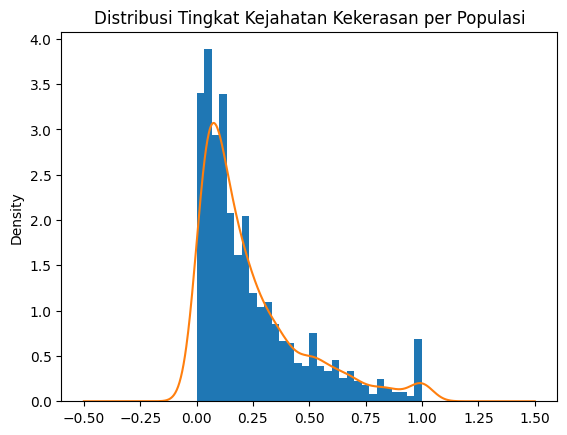

In [ ]:
df_eks['ViolentCrimesPerPop'].plot(kind='hist', bins=30, density=True)
df_eks['ViolentCrimesPerPop'].plot(kind='kde')

plt.title('Distribusi Tingkat Kejahatan Kekerasan per Populasi')
plt.show()

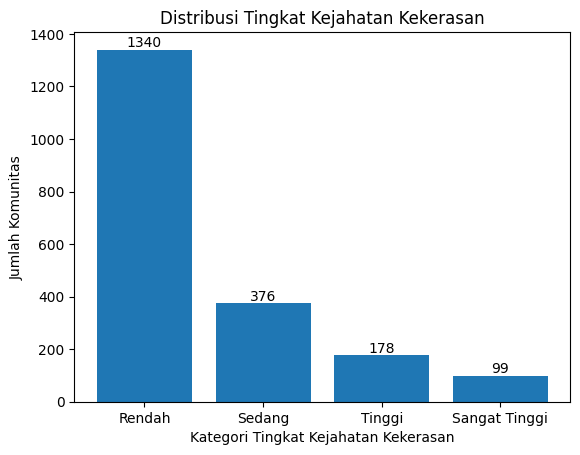

In [ ]:
def kategori(x):
    if x <= 0.25:
        return 'Rendah'
    elif x <= 0.5:
        return 'Sedang'
    elif x <= 0.75:
        return 'Tinggi'
    else:
        return 'Sangat Tinggi'

df_ekss = df_eks.copy()
df_ekss['crime_level'] = df_ekss['ViolentCrimesPerPop'].apply(kategori)
counts = df_ekss['crime_level'].value_counts()

plt.bar(counts.index, counts.values)
plt.xlabel('Kategori Tingkat Kejahatan Kekerasan')
plt.ylabel('Jumlah Komunitas')
plt.title('Distribusi Tingkat Kejahatan Kekerasan')

# Tambahin angka di atas bar
for i, v in enumerate(counts.values):
    plt.text(i, v + 10, str(v), ha='center')

plt.show()

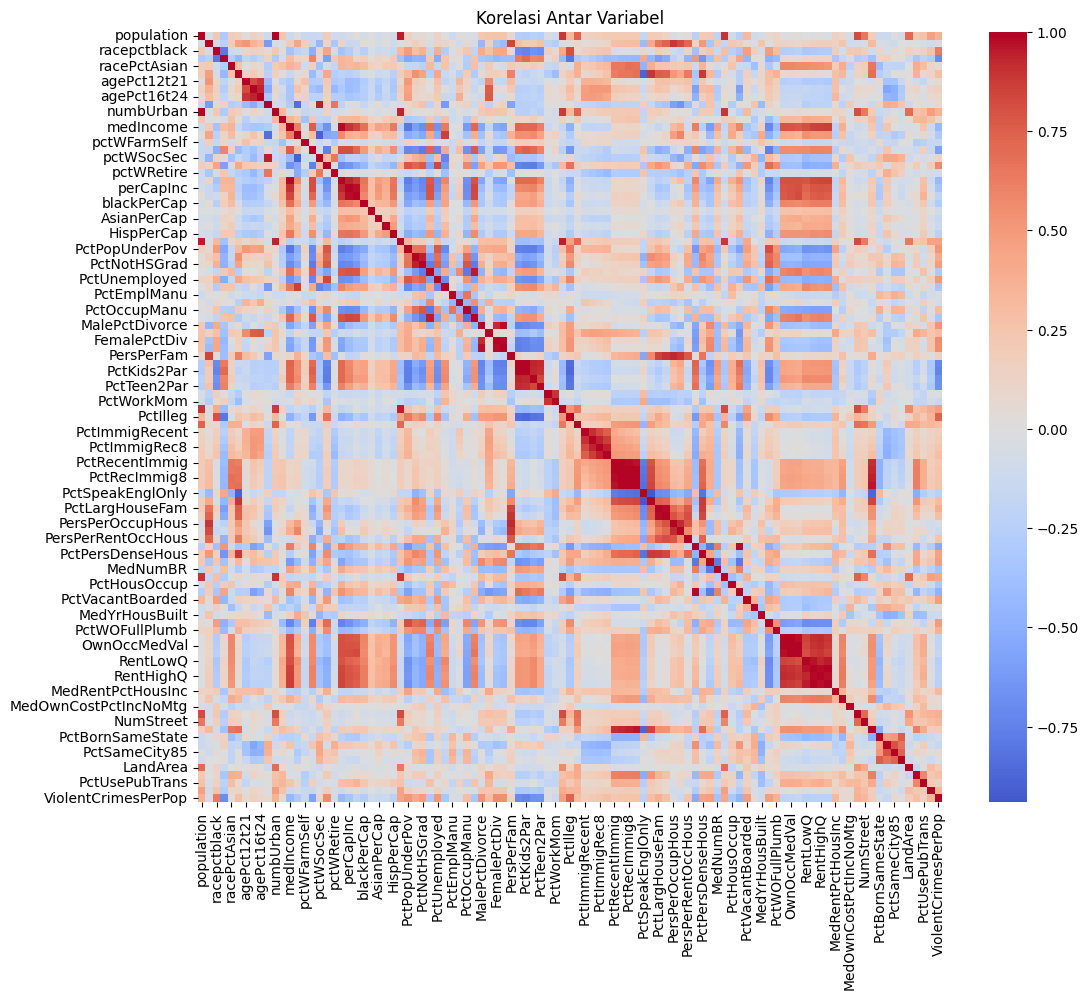

In [ ]:
# Korelasi
corr_matrix = df_eks.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Korelasi Antar Variabel")
plt.show()

# **Pemodelan Regresi**

In [ ]:
df_reg = df_eks.copy()

## **Split Data & Standarisasi**

In [ ]:
X = df_reg.drop(columns=['ViolentCrimesPerPop'])
y = df_reg['ViolentCrimesPerPop']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Simpan feature names
feature_names = X.columns.tolist()

print(f"\nData Train: {X_train_scaled.shape}")
print(f"Data Test: {X_test_scaled.shape}")


Data Train: (1594, 100)
Data Test: (399, 100)


## **Pemodelan**

In [ ]:
## Model
# Ridge (tanpa store_cv_values karena bertentangan dengan cv)
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge.fit(X_train_scaled, y_train)

# Lasso
lasso = LassoCV(alphas=np.logspace(-4, 2, 50), cv=5, max_iter=10000, random_state=42)
lasso.fit(X_train_scaled, y_train)

# Elastic Net
elastic = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1],
                       alphas=np.logspace(-4, 2, 30),
                       cv=5, max_iter=10000, random_state=42)
elastic.fit(X_train_scaled, y_train)

print(f"\nLambda terpilih:")
print(f"  Ridge: {ridge.alpha_:.4f}")
print(f"  Lasso: {lasso.alpha_:.4f}")
print(f"  Elastic Net: {elastic.alpha_:.4f}")
print(f"  L1 Ratio Elastic Net: {elastic.l1_ratio_:.4f}")


Lambda terpilih:
  Ridge: 59.6362
  Lasso: 0.0007
  Elastic Net: 0.0045
  L1 Ratio Elastic Net: 0.1000


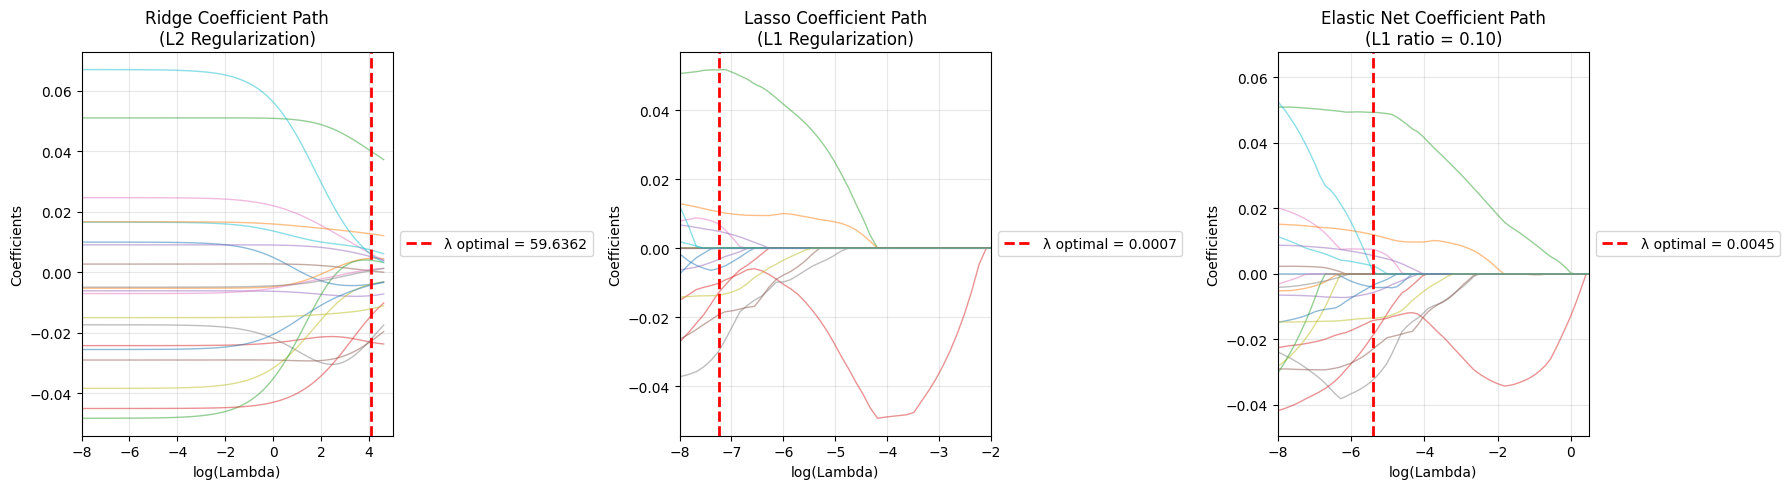

In [ ]:
# Coefficient Path Plot
# Buat range lambda
alphas = np.logspace(-4, 2, 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ridge Coefficient Path
ridge_coefs = []
for alpha in alphas:
    ridge_temp = Ridge(alpha=alpha)
    ridge_temp.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge_temp.coef_)
ridge_coefs = np.array(ridge_coefs)

log_lambda = np.log(alphas)

for i in range(min(20, len(feature_names))):
    axes[0].plot(log_lambda, ridge_coefs[:, i], alpha=0.5, linewidth=1)
axes[0].axvline(np.log(ridge.alpha_), color='r', linestyle='--', linewidth=2,
                label=f'λ optimal = {ridge.alpha_:.4f}')
axes[0].set_xlabel('log(Lambda)')
axes[0].set_ylabel('Coefficients')
axes[0].set_title(f'Ridge Coefficient Path\n(L2 Regularization)')
axes[0].set_xlim(-8, 5)
axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axes[0].grid(True, alpha=0.3)

# Lasso Coefficient Path
lasso_coefs = []
for alpha in alphas:
    lasso_temp = Lasso(alpha=alpha, max_iter=10000)
    lasso_temp.fit(X_train_scaled, y_train)
    lasso_coefs.append(lasso_temp.coef_)
lasso_coefs = np.array(lasso_coefs)

for i in range(min(20, len(feature_names))):
    axes[1].plot(log_lambda, lasso_coefs[:, i], alpha=0.5, linewidth=1)
axes[1].axvline(np.log(lasso.alpha_), color='r', linestyle='--', linewidth=2,
                label=f'λ optimal = {lasso.alpha_:.4f}')
axes[1].set_xlabel('log(Lambda)')
axes[1].set_ylabel('Coefficients')
axes[1].set_title(f'Lasso Coefficient Path\n(L1 Regularization)')
axes[1].set_xlim(-8, -2)
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axes[1].grid(True, alpha=0.3)

# Elastic Net Coefficient Path
elastic_coefs = []
for alpha in alphas:
    elastic_temp = ElasticNet(alpha=alpha, l1_ratio=elastic.l1_ratio_, max_iter=10000)
    elastic_temp.fit(X_train_scaled, y_train)
    elastic_coefs.append(elastic_temp.coef_)
elastic_coefs = np.array(elastic_coefs)

for i in range(min(20, len(feature_names))):
    axes[2].plot(log_lambda, elastic_coefs[:, i], alpha=0.5, linewidth=1)
axes[2].axvline(np.log(elastic.alpha_), color='r', linestyle='--', linewidth=2,
                label=f'λ optimal = {elastic.alpha_:.4f}')
axes[2].set_xlabel('log(Lambda)')
axes[2].set_ylabel('Coefficients')
axes[2].set_title(f'Elastic Net Coefficient Path\n(L1 ratio = {elastic.l1_ratio_:.2f})')
axes[2].set_xlim(-8, 0.5)
axes[2].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('coefficient_paths.png', dpi=100, bbox_inches='tight')
plt.show()


PERBANDINGAN KOEFISIEN (10 FITUR PERTAMA):
      Feature     Ridge  ElasticNet     Lasso
   population -0.004029   -0.003973 -0.005763
householdsize  0.004585    0.000000  0.000000
 racepctblack  0.039959    0.049331  0.051737
 racePctWhite -0.023198   -0.014193 -0.010111
 racePctAsian -0.007782   -0.005673 -0.003192
  racePctHisp  0.000395   -0.000000 -0.000000
  agePct12t21  0.005998    0.007577  0.006897
  agePct12t29 -0.022104   -0.032441 -0.029663
  agePct16t24 -0.003977    0.000000  0.000000
   agePct65up  0.007265    0.002355  0.000000


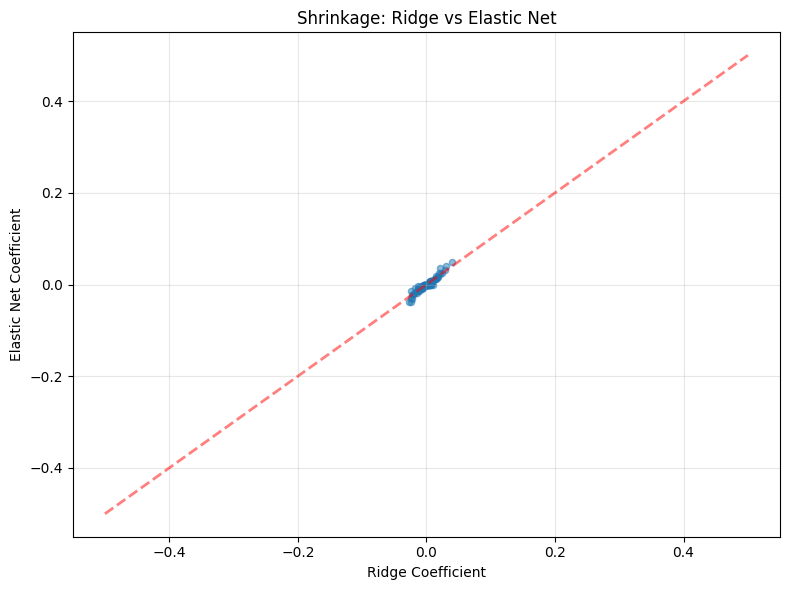

In [ ]:
# Perbandingan Shrinkage Ridge vs Elastic Net
ridge_coef = ridge.coef_
elastic_coef = elastic.coef_
lasso_coef = lasso.coef_

comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'Ridge': ridge_coef,
    'ElasticNet': elastic_coef,
    'Lasso': lasso_coef
})

print("\n" + "="*70)
print("PERBANDINGAN KOEFISIEN (10 FITUR PERTAMA):")
print("="*70)
print(comparison_df.head(10).to_string(index=False))

# Visualisasi shrinkage
fig, ax = plt.subplots(1, 1, figsize=(8, 6))  # ← 1 baris, 1 kolom → ax (bukan array)

# Ridge vs Elastic Net
ax.scatter(ridge_coef, elastic_coef, alpha=0.5, s=20)
ax.plot([-0.5, 0.5], [-0.5, 0.5], 'r--', alpha=0.5, linewidth=2)
ax.set_xlabel('Ridge Coefficient')
ax.set_ylabel('Elastic Net Coefficient')
ax.set_title('Shrinkage: Ridge vs Elastic Net')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('shrinkage_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

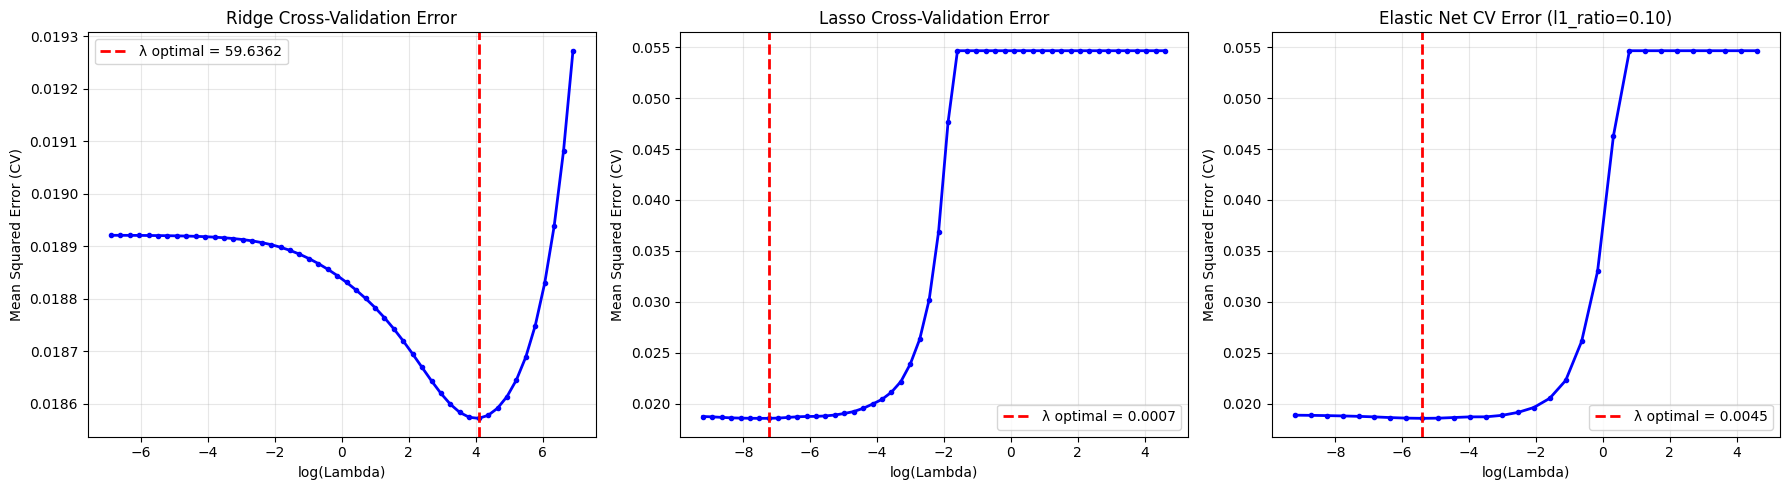

In [ ]:
# CROSS-VALIDATION ERROR PLOT
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ridge CV Error
mse_ridge = []
for alpha in ridge.alphas:
    ridge_temp = Ridge(alpha=alpha)
    scores = -cross_val_score(ridge_temp, X_train_scaled, y_train,
                               cv=5, scoring='neg_mean_squared_error')
    mse_ridge.append(scores.mean())

axes[0].plot(np.log(ridge.alphas), mse_ridge, 'b-o', markersize=3, linewidth=2)
axes[0].axvline(np.log(ridge.alpha_), color='r', linestyle='--', linewidth=2,
                label=f'λ optimal = {ridge.alpha_:.4f}')
axes[0].set_xlabel('log(Lambda)')
axes[0].set_ylabel('Mean Squared Error (CV)')
axes[0].set_title('Ridge Cross-Validation Error')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Lasso CV Error
axes[1].plot(np.log(lasso.alphas_), np.mean(lasso.mse_path_, axis=1),
             'b-o', markersize=3, linewidth=2)
axes[1].axvline(np.log(lasso.alpha_), color='r', linestyle='--', linewidth=2,
                label=f'λ optimal = {lasso.alpha_:.4f}')
axes[1].set_xlabel('log(Lambda)')
axes[1].set_ylabel('Mean Squared Error (CV)')
axes[1].set_title('Lasso Cross-Validation Error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Elastic Net CV Error (untuk l1_ratio terbaik)
best_l1_idx = list(elastic.l1_ratio).index(elastic.l1_ratio_)
mse_elastic_best = np.mean(elastic.mse_path_[best_l1_idx], axis=1)
axes[2].plot(np.log(elastic.alphas_), mse_elastic_best, 'b-o', markersize=3, linewidth=2)
axes[2].axvline(np.log(elastic.alpha_), color='r', linestyle='--', linewidth=2,
                label=f'λ optimal = {elastic.alpha_:.4f}')
axes[2].set_xlabel('log(Lambda)')
axes[2].set_ylabel('Mean Squared Error (CV)')
axes[2].set_title(f'Elastic Net CV Error (l1_ratio={elastic.l1_ratio_:.2f})')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cv_errors.png', dpi=100, bbox_inches='tight')
plt.show()


PLOT CV ERROR DENGAN STANDARD DEVIATION


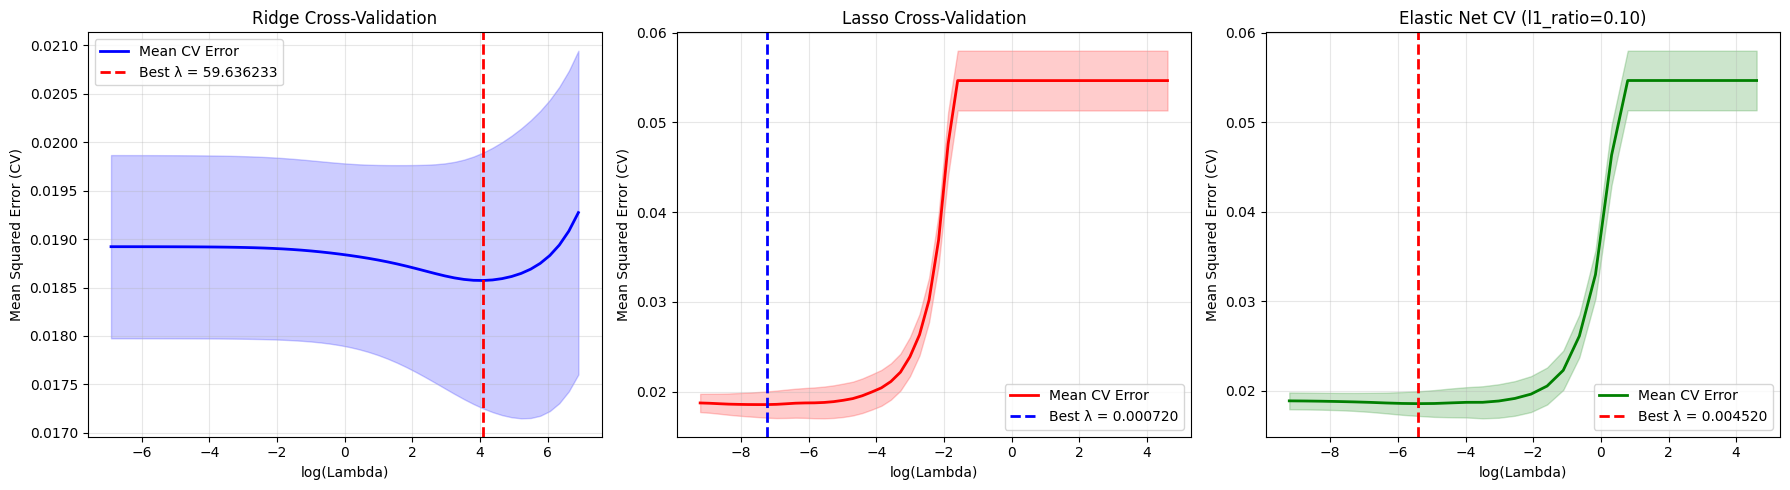

In [ ]:
# ============================================
# PLOT CV ERROR DENGAN SHADED REGION (Ridge)
# ============================================
print("\n" + "="*70)
print("PLOT CV ERROR DENGAN STANDARD DEVIATION")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ridge dengan shaded region
alphas_ridge = ridge.alphas
ridge_errors = []
ridge_stds = []
for alpha in alphas_ridge:
    ridge_temp = Ridge(alpha=alpha)
    scores = cross_val_score(ridge_temp, X_train_scaled, y_train,
                              cv=5, scoring='neg_mean_squared_error')
    ridge_errors.append(-scores.mean())
    ridge_stds.append(scores.std())

ridge_errors = np.array(ridge_errors)
ridge_stds = np.array(ridge_stds)

axes[0].plot(np.log(alphas_ridge), ridge_errors, 'b-', linewidth=2, label='Mean CV Error')
axes[0].fill_between(np.log(alphas_ridge), ridge_errors - ridge_stds,
                      ridge_errors + ridge_stds, alpha=0.2, color='blue')
axes[0].axvline(np.log(ridge.alpha_), color='r', linestyle='--', linewidth=2,
                label=f'Best λ = {ridge.alpha_:.6f}')
axes[0].set_xlabel('log(Lambda)')
axes[0].set_ylabel('Mean Squared Error (CV)')
axes[0].set_title('Ridge Cross-Validation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Lasso dengan shaded region
alphas_lasso = lasso.alphas_
mse_lasso = np.mean(lasso.mse_path_, axis=1)
std_lasso = np.std(lasso.mse_path_, axis=1)

axes[1].plot(np.log(alphas_lasso), mse_lasso, 'r-', linewidth=2, label='Mean CV Error')
axes[1].fill_between(np.log(alphas_lasso), mse_lasso - std_lasso,
                      mse_lasso + std_lasso, alpha=0.2, color='red')
axes[1].axvline(np.log(lasso.alpha_), color='blue', linestyle='--', linewidth=2,
                label=f'Best λ = {lasso.alpha_:.6f}')
axes[1].set_xlabel('log(Lambda)')
axes[1].set_ylabel('Mean Squared Error (CV)')
axes[1].set_title('Lasso Cross-Validation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Elastic Net dengan shaded region
best_l1_idx = list(elastic.l1_ratio).index(elastic.l1_ratio_)
mse_elastic_best = np.mean(elastic.mse_path_[best_l1_idx], axis=1)
std_elastic_best = np.std(elastic.mse_path_[best_l1_idx], axis=1)
alphas_elastic = elastic.alphas_

axes[2].plot(np.log(alphas_elastic), mse_elastic_best, 'g-', linewidth=2, label='Mean CV Error')
axes[2].fill_between(np.log(alphas_elastic), mse_elastic_best - std_elastic_best,
                      mse_elastic_best + std_elastic_best, alpha=0.2, color='green')
axes[2].axvline(np.log(elastic.alpha_), color='red', linestyle='--', linewidth=2,
                label=f'Best λ = {elastic.alpha_:.6f}')
axes[2].set_xlabel('log(Lambda)')
axes[2].set_ylabel('Mean Squared Error (CV)')
axes[2].set_title(f'Elastic Net CV (l1_ratio={elastic.l1_ratio_:.2f})')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cv_plots_with_std.png', dpi=100, bbox_inches='tight')
plt.show()

## **Analisis Koefisien**

In [ ]:
# Jumlah koefisien non-nol (Lasso)
lasso_coef = lasso.coef_
non_zero_count = np.sum(np.abs(lasso_coef) > 1e-6)
zero_count = len(lasso_coef) - non_zero_count

print(f"\nJumlah koefisien nol: {zero_count}")
print(f"Jumlah koefisien non-nol: {non_zero_count}")
print(f"Persentase fitur terpilih: {non_zero_count/len(lasso_coef)*100:.1f}%")


Jumlah koefisien nol: 42
Jumlah koefisien non-nol: 58
Persentase fitur terpilih: 58.0%


In [ ]:
# Top 10 variabel terpenting model ridge
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': ridge_coef,
    'AbsCoefficient': np.abs(ridge_coef)
}).sort_values('AbsCoefficient', ascending=False)

top10 = coef_df.head(10)

print("\nTABEL KOEFISIEN TERPILIH (10 TERATAS) MODEL RIDGE:")
print("="*70)
print(top10[['Feature', 'Coefficient']].to_string(index=False))


TABEL KOEFISIEN TERPILIH (10 TERATAS) MODEL RIDGE:
         Feature  Coefficient
    racepctblack     0.039959
PctPersDenseHous     0.030133
        PctIlleg     0.028562
  PctPopUnderPov    -0.027696
        RentLowQ    -0.023848
     PctKids2Par    -0.023787
      HousVacant     0.023560
    racePctWhite    -0.023198
      pctWInvInc    -0.022784
     agePct12t29    -0.022104


In [ ]:
# Top 10 variabel terpenting model lasso
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_coef,
    'AbsCoefficient': np.abs(lasso_coef)
}).sort_values('AbsCoefficient', ascending=False)

top10 = coef_df.head(10)

print("\nTABEL KOEFISIEN TERPILIH (10 TERATAS) MODEL LASSO:")
print("="*70)
print(top10[['Feature', 'Coefficient']].to_string(index=False))


TABEL KOEFISIEN TERPILIH (10 TERATAS) MODEL LASSO:
         Feature  Coefficient
    racepctblack     0.051737
     PctKids2Par    -0.044097
PctPersDenseHous     0.038742
        PctIlleg     0.033335
  PctPopUnderPov    -0.033144
         MedRent     0.030278
     agePct12t29    -0.029663
        RentLowQ    -0.025733
      HousVacant     0.023391
  MalePctNevMarr     0.019532


In [ ]:
# Top 10 variabel terpenting model elastic net
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': elastic_coef,
    'AbsCoefficient': np.abs(elastic_coef)
}).sort_values('AbsCoefficient', ascending=False)

top10 = coef_df.head(10)

print("\nTABEL KOEFISIEN TERPILIH (10 TERATAS) ELASTIC NET:")
print("="*70)
print(top10[['Feature', 'Coefficient']].to_string(index=False))


TABEL KOEFISIEN TERPILIH (10 TERATAS) ELASTIC NET:
         Feature  Coefficient
    racepctblack     0.049331
PctPersDenseHous     0.041038
  PctPopUnderPov    -0.038809
     PctKids2Par    -0.037215
         MedRent     0.034987
     agePct12t29    -0.032441
        PctIlleg     0.030961
        RentLowQ    -0.029422
      HousVacant     0.025353
  MalePctNevMarr     0.024230


## **Evaluasi Model (Test Set)**

In [ ]:
# Prediksi
y_pred_ridge = ridge.predict(X_test_scaled)
y_pred_lasso = lasso.predict(X_test_scaled)
y_pred_elastic = elastic.predict(X_test_scaled)

# Fungsi evaluasi
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    return {'Model': model_name, 'RMSE': rmse, 'R²': r2, 'MAE': mae}

# Evaluasi
results = []
results.append(evaluate_model(y_test, y_pred_ridge, 'Ridge'))
results.append(evaluate_model(y_test, y_pred_lasso, 'Lasso'))
results.append(evaluate_model(y_test, y_pred_elastic, 'Elastic Net'))

results_df = pd.DataFrame(results)

print("\nTABEL METRIK EVALUASI:")
print("="*70)
print(results_df.to_string(index=False))


TABEL METRIK EVALUASI:
      Model     RMSE       R²      MAE
      Ridge 0.137166 0.645457 0.092670
      Lasso 0.136796 0.647366 0.092514
Elastic Net 0.136649 0.648122 0.092432


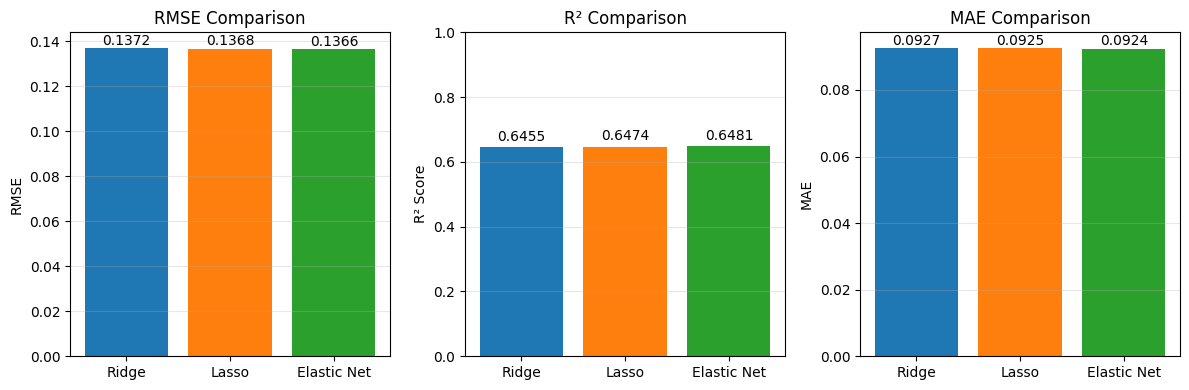

In [ ]:
# Visualisasi perbandingan
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# RMSE Comparison
bars1 = axes[0].bar(results_df['Model'], results_df['RMSE'],
                     color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE Comparison')
for bar, val in zip(bars1, results_df['RMSE']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                 f'{val:.4f}', ha='center', va='bottom')
axes[0].grid(True, alpha=0.3, axis='y')

# R² Comparison
bars2 = axes[1].bar(results_df['Model'], results_df['R²'],
                     color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('R² Score')
axes[1].set_title('R² Comparison')
for bar, val in zip(bars2, results_df['R²']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, 1)

# MAE Comparison
bars3 = axes[2].bar(results_df['Model'], results_df['MAE'],
                     color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[2].set_ylabel('MAE')
axes[2].set_title('MAE Comparison')
for bar, val in zip(bars3, results_df['MAE']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00005,
                 f'{val:.4f}', ha='center', va='bottom')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## **Prediction vs Actual Plot**

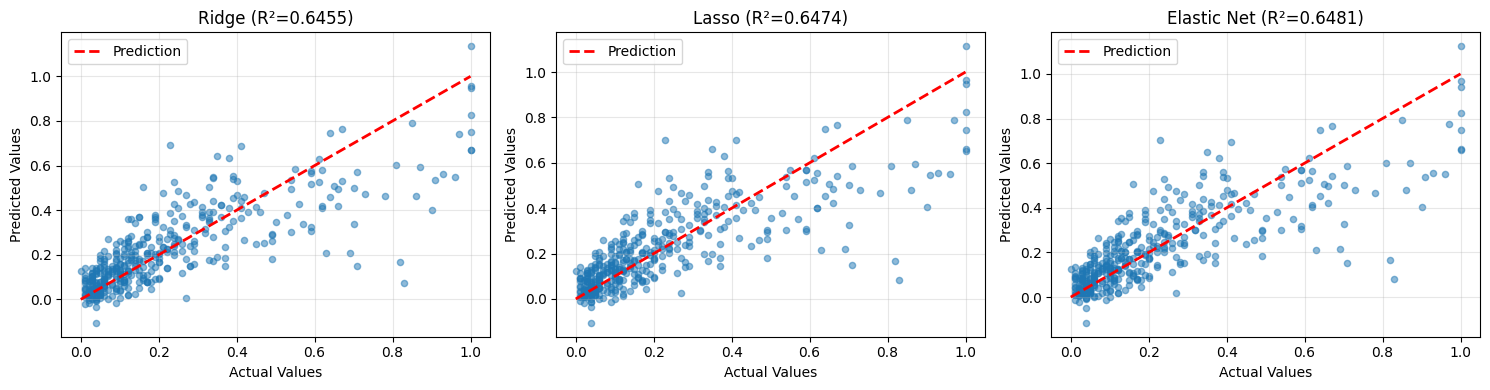

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Ridge
axes[0].scatter(y_test, y_pred_ridge, alpha=0.5, s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Prediction')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title(f'Ridge (R²={results_df[results_df["Model"]=="Ridge"]["R²"].values[0]:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Lasso
axes[1].scatter(y_test, y_pred_lasso, alpha=0.5, s=20)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Prediction')
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')
axes[1].set_title(f'Lasso (R²={results_df[results_df["Model"]=="Lasso"]["R²"].values[0]:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Elastic Net
axes[2].scatter(y_test, y_pred_elastic, alpha=0.5, s=20)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Prediction')
axes[2].set_xlabel('Actual Values')
axes[2].set_ylabel('Predicted Values')
axes[2].set_title(f'Elastic Net (R²={results_df[results_df["Model"]=="Elastic Net"]["R²"].values[0]:.4f})')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_vs_actual.png', dpi=100, bbox_inches='tight')
plt.show()

## **Interpretasi**

In [ ]:
# Tentukan model terbaik
best_model = results_df.loc[results_df['R²'].idxmax(), 'Model']
best_r2 = results_df.loc[results_df['R²'].idxmax(), 'R²']
best_rmse = results_df.loc[results_df['R²'].idxmax(), 'RMSE']

In [ ]:
print(f"\nModel Terbaik: {best_model}")
print(f"  R² = {best_r2:.4f}")
print(f"  RMSE = {best_rmse:.4f}")

print("\n" + "="*70)
print("PEMBAHASAN KONSEPTUAL")
print("="*70)

print("""
A. Mengapa Lasso Menarik pada Data Berdimensi Tinggi?
   Lasso (L1 regularization) melakukan seleksi fitur otomatis dengan mendorong
   koefisien variabel yang tidak penting menjadi nol. Pada dataset dengan 100+
   fitur, Lasso berhasil mereduksi dimensi secara signifikan (dalam analisis ini
   mereduksi dari {total_fitur} fitur menjadi {fitur_terpilih} fitur), sehingga:
   - Menghasilkan model yang lebih interpretable
   - Mengurangi risiko overfitting
   - Memudahkan identifikasi faktor-faktor kunci yang mempengaruhi kejahatan

B. Mengapa Ridge Tetap Relevan dengan Korelasi Antar Prediktor?
   Ridge (L2 regularization) tidak melakukan seleksi fitur, tetapi menshrink
   koefisien secara proporsional. Keunggulannya pada data dengan multikolinearitas:
   - Koefisien variabel yang berkorelasi tinggi cenderung di-shrink bersama-sama
   - Tidak memilih satu variabel secara arbitrer seperti potensi Lasso
   - Menghasilkan estimasi yang lebih stabil secara statistik
   - Pada dataset sosio-ekonomi (pendapatan, pendidikan, pekerjaan saling berkorelasi),
     Ridge memberikan estimasi yang lebih konsisten

C. Mengapa Elastic Net Menjadi Kompromi yang Kuat?
   Elastic Net menggabungkan kelebihan Ridge dan Lasso:
   - Parameter l1_ratio mengontrol keseimbangan antara L1 (Lasso) dan L2 (Ridge)
   - Dapat melakukan seleksi fitur seperti Lasso sekaligus stabil terhadap korelasi
   - Nilai l1_ratio = {l1_ratio:.2f} dalam analisis ini menunjukkan kecenderungan
     ke Lasso, tetapi tetap mempertahankan stabilitas Ridge untuk variabel berkorelasi
   - Ideal untuk data dengan banyak fitur yang saling berkorelasi
""".format(total_fitur=len(feature_names),
           fitur_terpilih=non_zero_count,
           l1_ratio=elastic.l1_ratio_))

print("\n" + "="*70)
print("REKOMENDASI MODEL TERBAIK")
print("="*70)

print(f"""
Berdasarkan hasil analisis pada dataset Communities and Crime dengan
{len(feature_names)} variabel prediktor dan {df_clean.shape[0]} sampel:

REKOMENDASI: {best_model}

ALASAN STATISTIK:
1. {best_model} memberikan nilai R² tertinggi ({best_r2:.4f}) di antara ketiga model
2. {best_model} memiliki RMSE terendah ({best_rmse:.4f}) yang menunjukkan error prediksi terkecil
3. {'Elastic Net berhasil menyeimbangkan seleksi fitur dan stabilitas' if best_model == 'Elastic Net'
   else 'Model ini konsisten dengan performa terbaik'}

ALASAN PRAKTIS:
1. {'Elastic Net secara otomatis memilih variabel penting sekaligus stabil terhadap korelasi'
   if best_model == 'Elastic Net'
   else 'Model ini mudah diinterpretasikan dan stabil untuk prediksi'}
2. {'Nilai l1_ratio = ' + f'{elastic.l1_ratio_:.2f}' + ' menunjukkan model dapat menyesuaikan dengan struktur data'
   if best_model == 'Elastic Net'
   else 'Model ini cocok untuk konteks data dengan karakteristik tertentu'}
3. Model ini dapat digunakan untuk memprediksi tingkat kejahatan kekerasan di komunitas baru
   berdasarkan karakteristik demografi, ekonomi, dan struktur keluarga

KETERBATASAN:
- Data berasal dari tahun 1990-1995, perlu validasi dengan data terkini
- Model linear tidak menangkap efek non-linear atau interaksi kompleks
- Normalisasi 0-1 membatasi interpretasi dalam unit asli
""")


Model Terbaik: Elastic Net
  R² = 0.6481
  RMSE = 0.1366

PEMBAHASAN KONSEPTUAL

A. Mengapa Lasso Menarik pada Data Berdimensi Tinggi?
   Lasso (L1 regularization) melakukan seleksi fitur otomatis dengan mendorong
   koefisien variabel yang tidak penting menjadi nol. Pada dataset dengan 100+
   fitur, Lasso berhasil mereduksi dimensi secara signifikan (dalam analisis ini
   mereduksi dari 100 fitur menjadi 58 fitur), sehingga:
   - Menghasilkan model yang lebih interpretable
   - Mengurangi risiko overfitting
   - Memudahkan identifikasi faktor-faktor kunci yang mempengaruhi kejahatan

B. Mengapa Ridge Tetap Relevan dengan Korelasi Antar Prediktor?
   Ridge (L2 regularization) tidak melakukan seleksi fitur, tetapi menshrink
   koefisien secara proporsional. Keunggulannya pada data dengan multikolinearitas:
   - Koefisien variabel yang berkorelasi tinggi cenderung di-shrink bersama-sama
   - Tidak memilih satu variabel secara arbitrer seperti potensi Lasso
   - Menghasilkan estimasi ya

# **Kesimpulan**

In [ ]:
## KESIMPULAN
print("\n" + "="*70)
print("KESIMPULAN")
print("="*70)

print(f"""
ANALISIS REGRESI REGULARISASI UNTUK PREDIKSI TINGKAT KEJAHATAN
================================================================

Dataset: Communities and Crime (UCI Repository)
Jumlah Sampel: {df_clean.shape[0]} komunitas
Jumlah Fitur: {df_clean.shape[1] - 1} variabel (demografi, ekonomi, struktur keluarga)
Target: ViolentCrimesPerPop (kejahatan kekerasan per 100.000 penduduk)

HASIL UTAMA:
1. Model terbaik: {best_model}
   - R² = {best_r2:.4f} (menjelaskan {best_r2*100:.1f}% variansi data)
   - RMSE = {best_rmse:.4f} (dalam skala 0-1 yang telah dinormalisasi)

2. Seleksi fitur Lasso:
   - Mereduksi dari {len(feature_names)} fitur menjadi {non_zero_count} fitur
   - Penghematan dimensi: {zero_count} fitur ({zero_count/len(feature_names)*100:.1f}%)

3. 5 Variabel terpenting:
   {chr(10).join([f'   {i+1}. {row["Feature"]}: koefisien = {row["Coefficient"]:+.4f}'
                   for i, row in top10.head(5).iterrows()])}

KESIMPULAN:
{best_model} direkomendasikan sebagai model terbaik untuk memprediksi tingkat
kejahatan kekerasan di komunitas. Model ini berhasil menyeimbangkan akurasi
prediksi dengan interpretabilitas, serta mampu mengidentifikasi faktor-faktor
kunci yang mempengaruhi tingkat kejahatan.
""")


KESIMPULAN

ANALISIS REGRESI REGULARISASI UNTUK PREDIKSI TINGKAT KEJAHATAN

Dataset: Communities and Crime (UCI Repository)
Jumlah Sampel: 1993 komunitas
Jumlah Fitur: 100 variabel (demografi, ekonomi, struktur keluarga)
Target: ViolentCrimesPerPop (kejahatan kekerasan per 100.000 penduduk)

HASIL UTAMA:
1. Model terbaik: Elastic Net
   - R² = 0.6481 (menjelaskan 64.8% variansi data)
   - RMSE = 0.1366 (dalam skala 0-1 yang telah dinormalisasi)

2. Seleksi fitur Lasso:
   - Mereduksi dari 100 fitur menjadi 58 fitur
   - Penghematan dimensi: 42 fitur (42.0%)

3. 5 Variabel terpenting:
      3. racepctblack: koefisien = +0.0493
   69. PctPersDenseHous: koefisien = +0.0410
   29. PctPopUnderPov: koefisien = -0.0388
   45. PctKids2Par: koefisien = -0.0372
   86. MedRent: koefisien = +0.0350

KESIMPULAN:
Elastic Net direkomendasikan sebagai model terbaik untuk memprediksi tingkat
kejahatan kekerasan di komunitas. Model ini berhasil menyeimbangkan akurasi
prediksi dengan interpretabilitas, 